# Objectif 

Analyse de la portion 1 extraite via le code acouplane_select_and_extract_portion1.ipynb

Date de création : 07/10/2026

In [1]:
import os
import sys
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.io import loadmat
from matplotlib.lines import Line2D
from datetime import datetime, timedelta

In [2]:
if os.name == "nt":  # Windows
    ROOT_PROGRAM = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"
else:  # Linux
    ROOT_PROGRAM = "/home/program/ubf_tools"
sys.path.append(ROOT_PROGRAM)

from publication.publication_figure import set_subfigures_abc_labels, color
from real_data_analysis.acouplane.src.acouplane_cst import *
from real_data_analysis.acouplane.src.acouplane_utils import *

# Chargement des données 

Les données sont stockées au format netcdf sous la forme d'un arbre (xarray DataTree) et regroupe l'ensemble des données associées à la portion d'intérêt. 

In [3]:
portion_id = 1
fpath = f"{ACOUPLANE_PORTION_NC_ROOT_FPATH}_{portion_id}.nc"
portion = xr.open_datatree(fpath)
portion

<xarray.DataTree>
Group: /
├── Group: /position
│   ├── Group: /position/sn1
│   │       Dimensions:                (rcv_id: 7, atl_datetime: 1144, mmsi: 526,
│   │                                   ais_datetime: 121, src_datetime: 390)
│   │       Coordinates:
│   │         * rcv_id                 (rcv_id) <U4 112B 'obs1' 'obs2' ... 'obs7' 'tlq'
│   │         * atl_datetime           (atl_datetime) datetime64[ns] 9kB 2026-02-25T09:50...
│   │         * ais_datetime           (ais_datetime) datetime64[ns] 968B 2026-02-25T09:5...
│   │         * src_datetime           (src_datetime) datetime64[ns] 3kB 2026-02-25T09:50...
│   │       Dimensions without coordinates: mmsi
│   │       Data variables: (12/13)
│   │           rcv_lon                (rcv_id) float64 56B ...
│   │           rcv_lat                (rcv_id) float64 56B ...
│   │           atl_lon                (atl_datetime) float64 9kB ...
│   │           atl_lat                (atl_datetime) float64 9kB ...
│   │           ais_lon                (mmsi, ais_datetime) float64 509kB ...
│   │           ais_lat                (mmsi, ais_datetime) float64 509kB ...
│   │           ...                     ...
│   │           tir_ECOS               (src_datetime) int64 3kB ...
│   │           tir_src_lon            (src_datetime) float64 3kB ...
│   │           tir_src_lat            (src_datetime) float64 3kB ...
│   │           tir_vessel_lon         (src_datetime) float64 3kB ...
│   │           tir_vessel_lat         (src_datetime) float64 3kB ...
│   │           src_rcv_geodesic_dist  (rcv_id, src_datetime) float64 22kB ...
│   │       Attributes:
│   │           description:              Positions AIS interpolées
│   │           interpolation_time_step:  10s
│   │           campagne:                 ACOUPLANE
│   │           geodesic_frame:           WGS84
│   │           portion_id:               1
│   │           section_orientation:      Sud/Nord
│   │           section_id:               0
│   ├── Group: /position/oe1
│   │       Dimensions:                (rcv_id: 7, atl_datetime: 600, mmsi: 526,
│   │                                   ais_datetime: 61, src_datetime: 200)
│   │       Coordinates:
│   │         * rcv_id                 (rcv_id) <U4 112B 'obs1' 'obs2' ... 'obs7' 'tlq'
│   │         * atl_datetime           (atl_datetime) datetime64[ns] 5kB 2026-02-25T00:42...
│   │         * ais_datetime           (ais_datetime) datetime64[ns] 488B 2026-02-25T00:4...
│   │         * src_datetime           (src_datetime) datetime64[ns] 2kB 2026-02-25T00:42...
│   │       Dimensions without coordinates: mmsi
│   │       Data variables: (12/13)
│   │           rcv_lon                (rcv_id) float64 56B ...
│   │           rcv_lat                (rcv_id) float64 56B ...
│   │           atl_lon                (atl_datetime) float64 5kB ...
│   │           atl_lat                (atl_datetime) float64 5kB ...
│   │           ais_lon                (mmsi, ais_datetime) float64 257kB ...
│   │           ais_lat                (mmsi, ais_datetime) float64 257kB ...
│   │           ...                     ...
│   │           tir_ECOS               (src_datetime) int64 2kB ...
│   │           tir_src_lon            (src_datetime) float64 2kB ...
│   │           tir_src_lat            (src_datetime) float64 2kB ...
│   │           tir_vessel_lon         (src_datetime) float64 2kB ...
│   │           tir_vessel_lat         (src_datetime) float64 2kB ...
│   │           src_rcv_geodesic_dist  (rcv_id, src_datetime) float64 11kB ...
│   │       Attributes:
│   │           description:              Positions AIS interpolées
│   │           interpolation_time_step:  10s
│   │           campagne:                 ACOUPLANE
│   │           geodesic_frame:           WGS84
│   │           portion_id:               1
│   │           section_orientation:      Ouest/Est
│   │           section_id:               1
│   ├── Group: /position/oe2
│   │       Dimensions:                (rcv_id: 

# Rappel de la position de la portion 

(<Figure size 1600x800 with 1 Axes>,
 <Axes: title={'center': 'OBS positions'}, xlabel='Longitude [°]', ylabel='Latitude [°]'>)

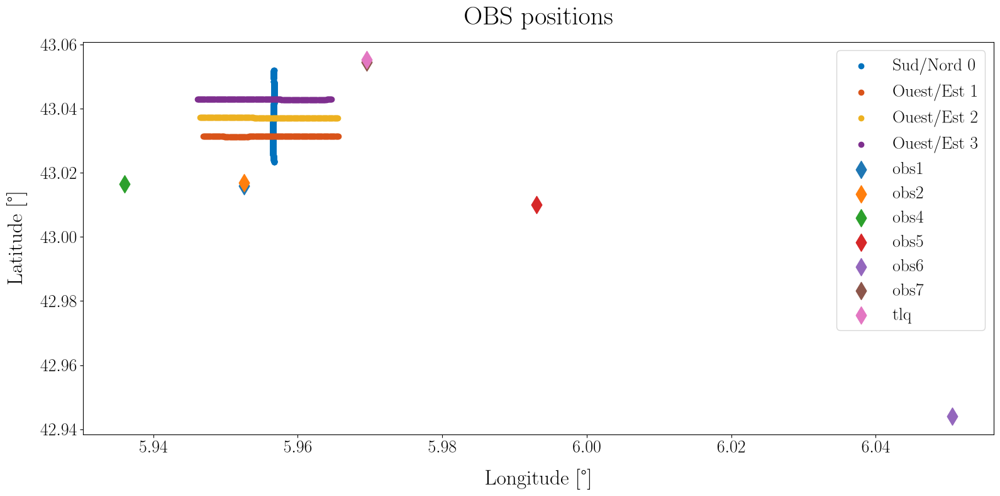

In [4]:
plot_portion_tir_pos(portion_tree=portion)

# Visualisation des données de pression

## Signaux

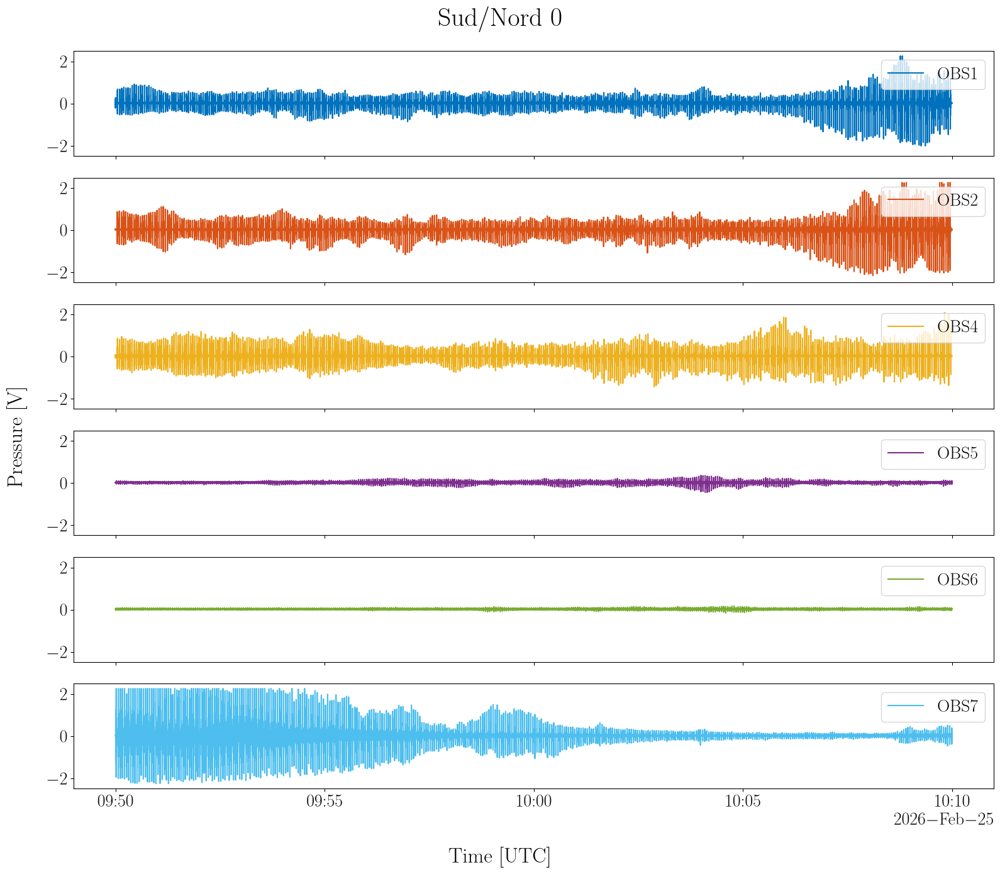

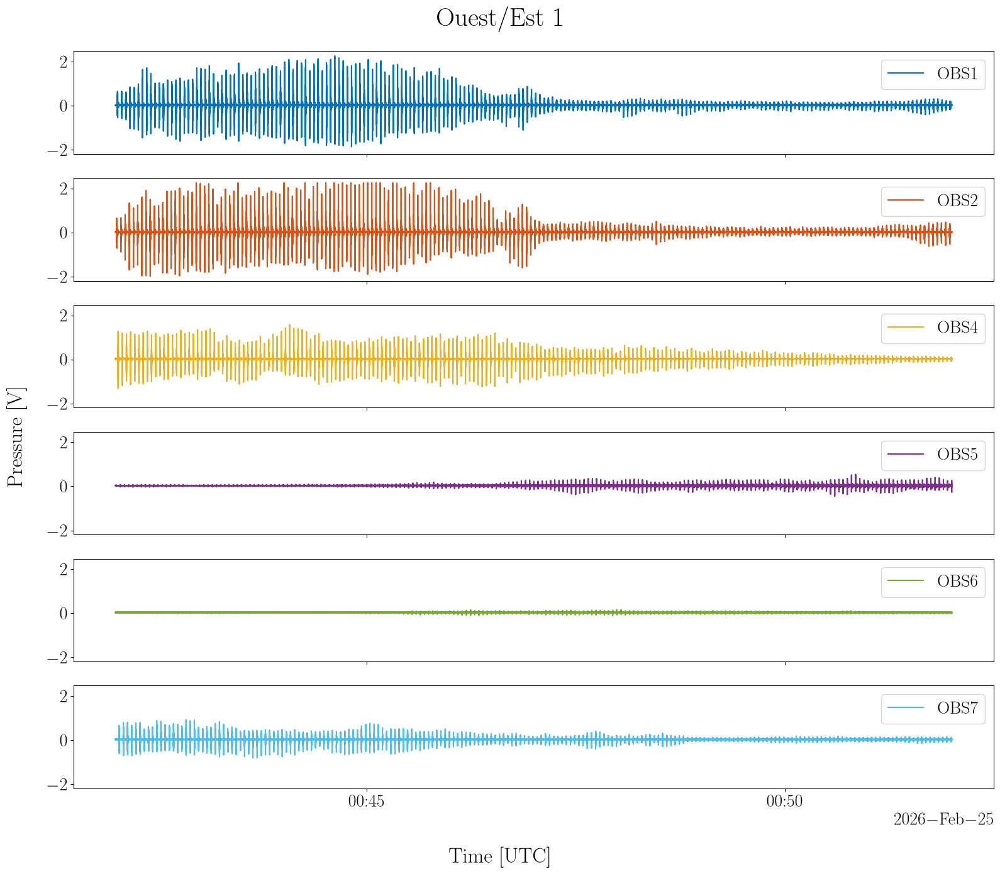

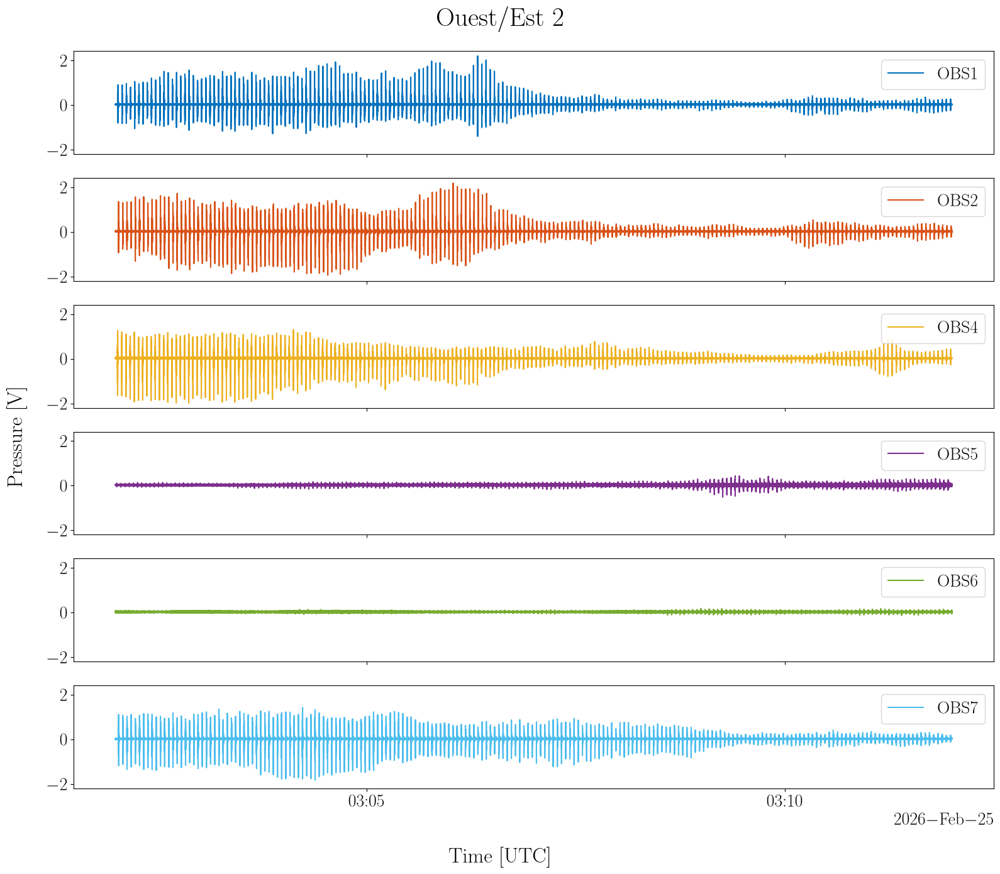

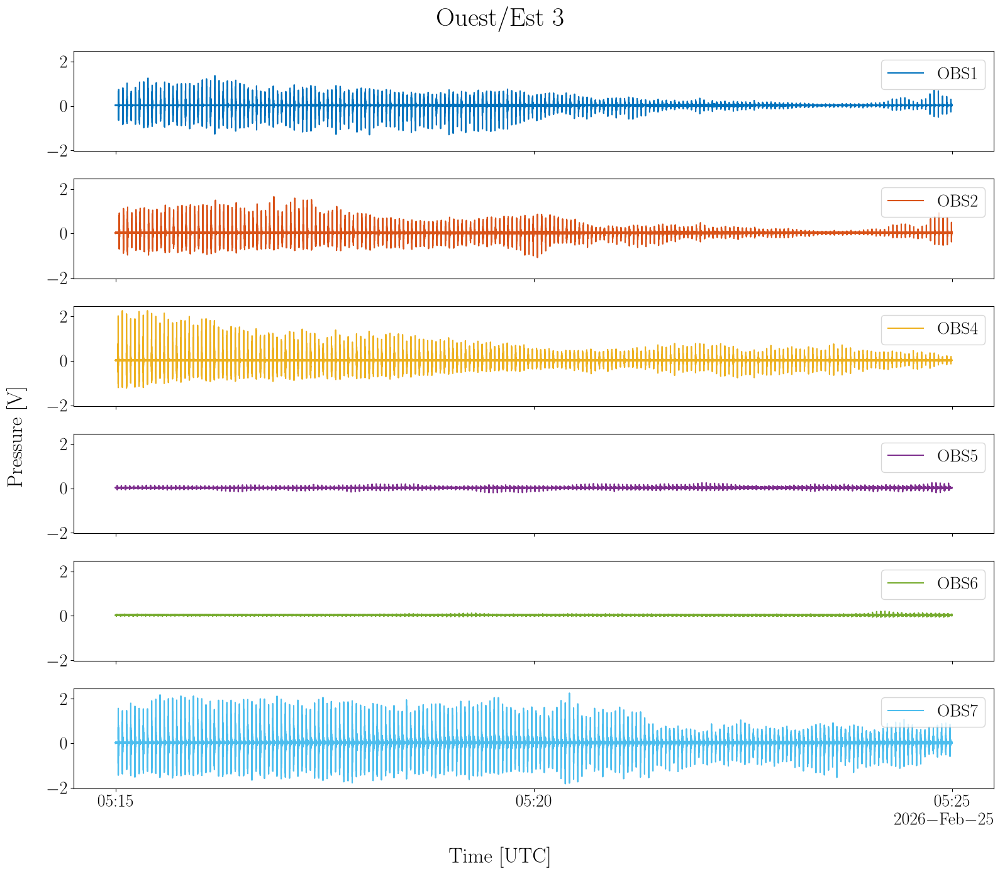

In [5]:
# Plot 
single_fig = False
for name, node in portion.pressure.children.items():
    ds_pressure_section = node.to_dataset()
    fig, axs = plot_pressure_section(ds_pressure_section=ds_pressure_section, single_fig=single_fig)
    fig.suptitle(f"{ds_pressure_section.section_orientation} {ds_pressure_section.section_id}")
    plt.show()

## Spectrogrames 

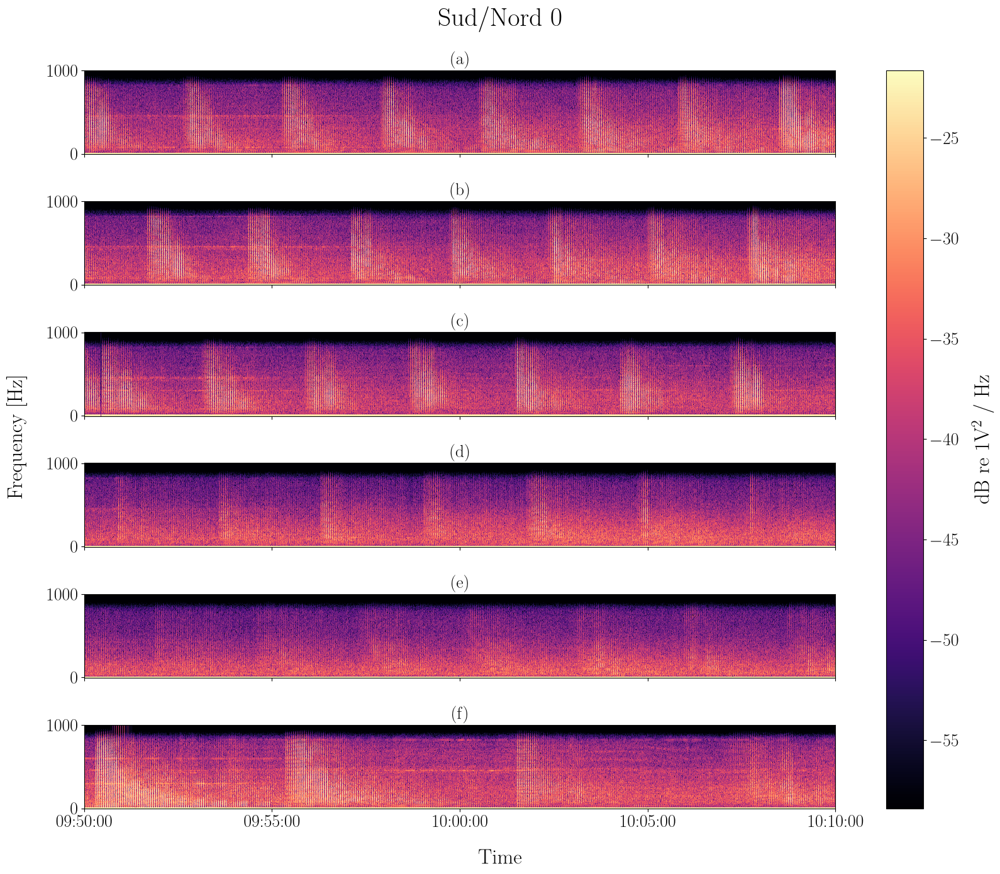

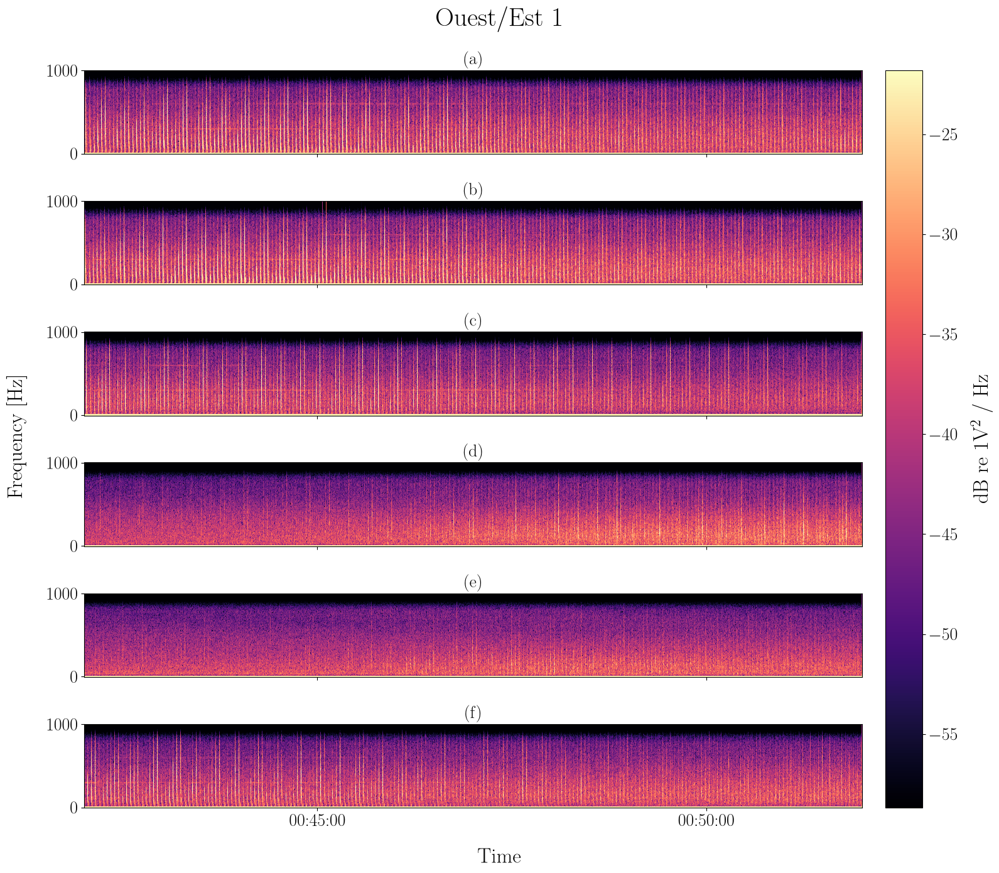

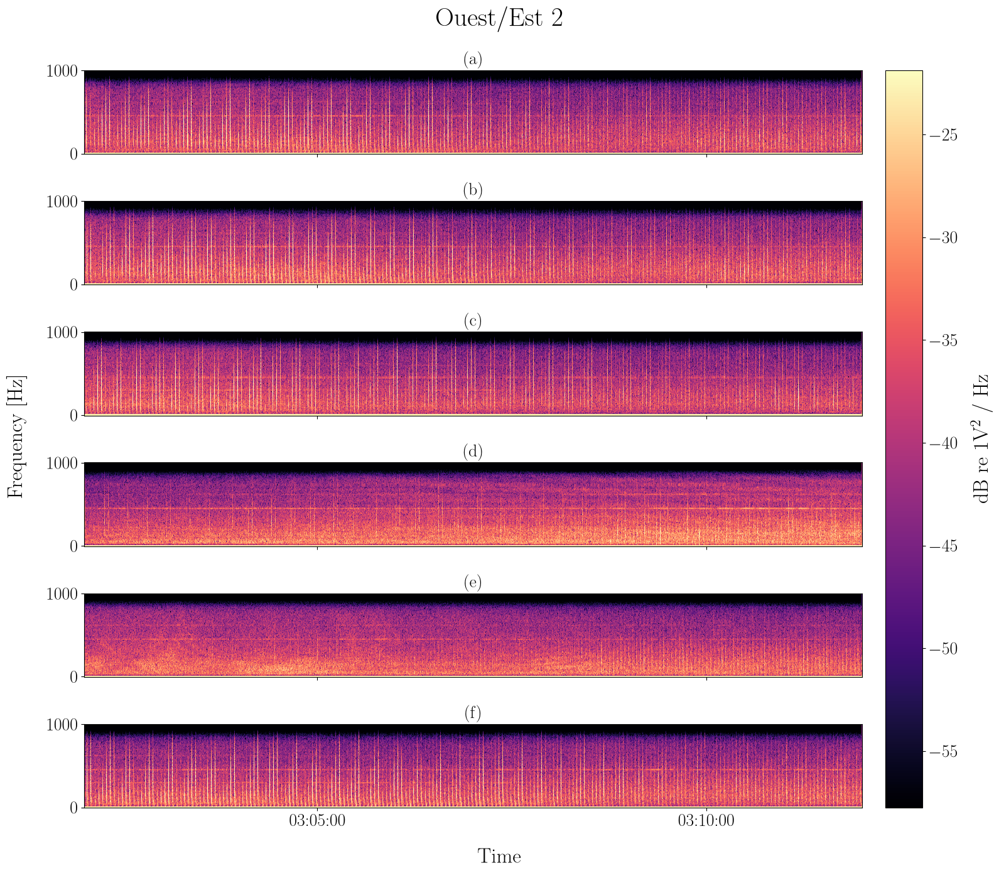

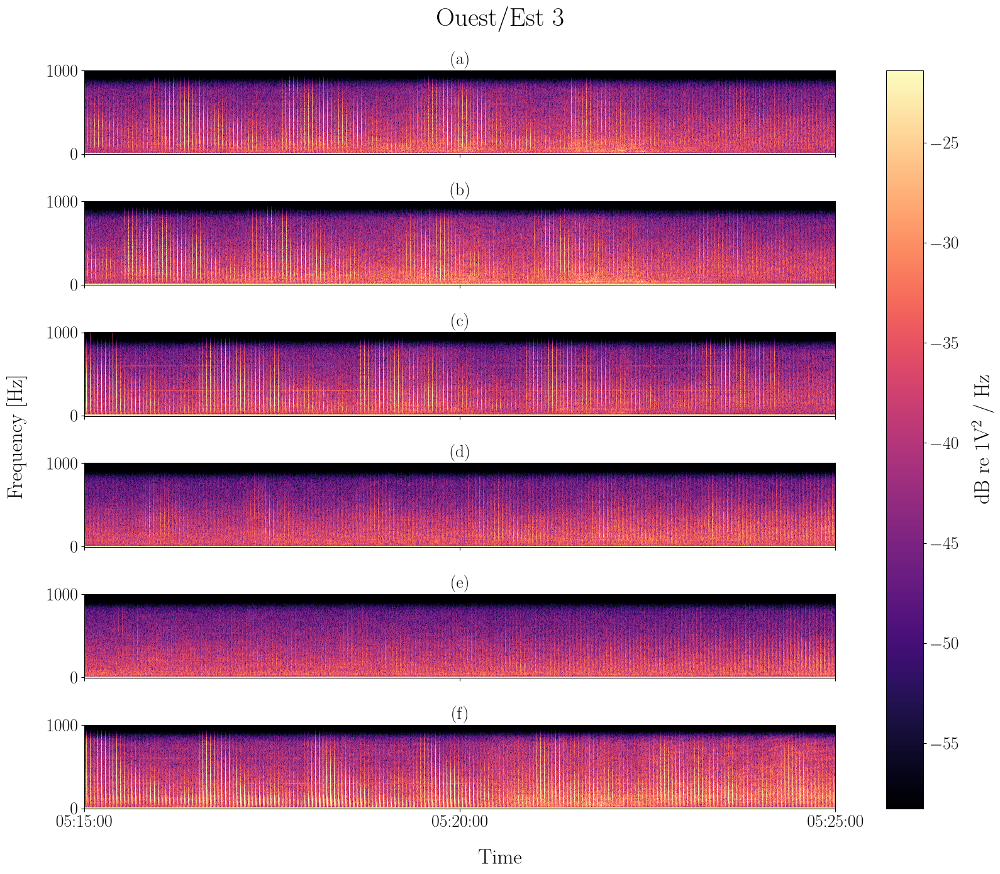

In [6]:
# Plot 
for name, node in portion.pressure.children.items():
    ds_pressure_section = node.to_dataset()
    fig, axs = plot_spectrogram_section(ds_pressure_section, nperseg=2**8, noverlap=2**7, cmap="magma")
    fig.suptitle(f"{ds_pressure_section.section_orientation} {ds_pressure_section.section_id}")
    plt.show()

# Calcul des grandeurs signantes 

In [7]:
portion

<xarray.DataTree>
Group: /
├── Group: /position
│   ├── Group: /position/sn1
│   │       Dimensions:                (rcv_id: 7, atl_datetime: 1144, mmsi: 526,
│   │                                   ais_datetime: 121, src_datetime: 390)
│   │       Coordinates:
│   │         * rcv_id                 (rcv_id) <U4 112B 'obs1' 'obs2' ... 'obs7' 'tlq'
│   │         * atl_datetime           (atl_datetime) datetime64[ns] 9kB 2026-02-25T09:50...
│   │         * ais_datetime           (ais_datetime) datetime64[ns] 968B 2026-02-25T09:5...
│   │         * src_datetime           (src_datetime) datetime64[ns] 3kB 2026-02-25T09:50...
│   │       Dimensions without coordinates: mmsi
│   │       Data variables: (12/13)
│   │           rcv_lon                (rcv_id) float64 56B ...
│   │           rcv_lat                (rcv_id) float64 56B ...
│   │           atl_lon                (atl_datetime) float64 9kB ...
│   │           atl_lat                (atl_datetime) float64 9kB ...
│   │           ais_lon                (mmsi, ais_datetime) float64 509kB ...
│   │           ais_lat                (mmsi, ais_datetime) float64 509kB ...
│   │           ...                     ...
│   │           tir_ECOS               (src_datetime) int64 3kB ...
│   │           tir_src_lon            (src_datetime) float64 3kB 5.957 5.957 ... 5.957
│   │           tir_src_lat            (src_datetime) float64 3kB 43.05 43.05 ... 43.02
│   │           tir_vessel_lon         (src_datetime) float64 3kB ...
│   │           tir_vessel_lat         (src_datetime) float64 3kB ...
│   │           src_rcv_geodesic_dist  (rcv_id, src_datetime) float64 22kB ...
│   │       Attributes:
│   │           description:              Positions AIS interpolées
│   │           interpolation_time_step:  10s
│   │           campagne:                 ACOUPLANE
│   │           geodesic_frame:           WGS84
│   │           portion_id:               1
│   │           section_orientation:      Sud/Nord
│   │           section_id:               0
│   ├── Group: /position/oe1
│   │       Dimensions:                (rcv_id: 7, atl_datetime: 600, mmsi: 526,
│   │                                   ais_datetime: 61, src_datetime: 200)
│   │       Coordinates:
│   │         * rcv_id                 (rcv_id) <U4 112B 'obs1' 'obs2' ... 'obs7' 'tlq'
│   │         * atl_datetime           (atl_datetime) datetime64[ns] 5kB 2026-02-25T00:42...
│   │         * ais_datetime           (ais_datetime) datetime64[ns] 488B 2026-02-25T00:4...
│   │         * src_datetime           (src_datetime) datetime64[ns] 2kB 2026-02-25T00:42...
│   │       Dimensions without coordinates: mmsi
│   │       Data variables: (12/13)
│   │           rcv_lon                (rcv_id) float64 56B ...
│   │           rcv_lat                (rcv_id) float64 56B ...
│   │           atl_lon                (atl_datetime) float64 5kB ...
│   │           atl_lat                (atl_datetime) float64 5kB ...
│   │           ais_lon                (mmsi, ais_datetime) float64 257kB ...
│   │           ais_lat                (mmsi, ais_datetime) float64 257kB ...
│   │           ...                     ...
│   │           tir_ECOS               (src_datetime) int64 2kB ...
│   │           tir_src_lon            (src_datetime) float64 2kB 5.947 5.947 ... 5.966
│   │           tir_src_lat            (src_datetime) float64 2kB 43.03 43.03 ... 43.03
│   │           tir_vessel_lon         (src_datetime) float64 2kB ...
│   │           tir_vessel_lat         (src_datetime) float64 2kB ...
│   │           src_rcv_geodesic_dist  (rcv_id, src_datetime) float64 11kB ...
│   │       Attributes:
│   │           description:              Positions AIS interpolées
│   │           interpolation_time_step:  10s
│   │           campagne:                 ACOUPLANE
│   │           geodesic_frame:           WGS84
│   │           portion_id:               1
│   │           section_orientation:      Ouest/Est
│   │           section_id:               1
│   ├

## Extraction de chaques émissions

### Calcul des temps de propagation associés à chaque couple émission / récepteur 

In [24]:
c0 = 1500
for name, node in portion.position.children.items():
    ds_pos_section = node.to_dataset()
    # Compute propagation time 
    tps_propagation_s = ds_pos_section.src_rcv_geodesic_dist / c0 
    ds_pos_section["tps_propagation_s"] = tps_propagation_s

    # Derive associated arrival dt 
    tps_propagation_ns = (tps_propagation_s * 1e9).round()
    tps_propagation_td = tps_propagation_ns.astype("timedelta64[ns]")
    ds_pos_section["tir_reception_datetime"] = tps_propagation_td + ds_pos_section.src_datetime

    # Update tree
    node.ds = ds_pos_section

In [25]:
portion

<xarray.DataTree>
Group: /
├── Group: /position
│   ├── Group: /position/sn1
│   │       Dimensions:                 (rcv_id: 7, atl_datetime: 1144, mmsi: 526,
│   │                                    ais_datetime: 121, src_datetime: 390)
│   │       Coordinates:
│   │         * rcv_id                  (rcv_id) <U4 112B 'obs1' 'obs2' ... 'obs7' 'tlq'
│   │         * atl_datetime            (atl_datetime) datetime64[ns] 9kB 2026-02-25T09:5...
│   │         * ais_datetime            (ais_datetime) datetime64[ns] 968B 2026-02-25T09:...
│   │         * src_datetime            (src_datetime) datetime64[ns] 3kB 2026-02-25T09:5...
│   │       Dimensions without coordinates: mmsi
│   │       Data variables: (12/15)
│   │           rcv_lon                 (rcv_id) float64 56B ...
│   │           rcv_lat                 (rcv_id) float64 56B ...
│   │           atl_lon                 (atl_datetime) float64 9kB ...
│   │           atl_lat                 (atl_datetime) float64 9kB ...
│   │           ais_lon                 (mmsi, ais_datetime) float64 509kB ...
│   │           ais_lat                 (mmsi, ais_datetime) float64 509kB ...
│   │           ...                      ...
│   │           tir_src_lat             (src_datetime) float64 3kB 43.05 43.05 ... 43.02
│   │           tir_vessel_lon          (src_datetime) float64 3kB ...
│   │           tir_vessel_lat          (src_datetime) float64 3kB ...
│   │           src_rcv_geodesic_dist   (rcv_id, src_datetime) float64 22kB 4.015e+03 ......
│   │           tps_propagation_s       (rcv_id, src_datetime) float64 22kB 2.677 ... 2.47
│   │           tir_reception_datetime  (rcv_id, src_datetime) datetime64[ns] 22kB 2026-0...
│   │       Attributes:
│   │           description:              Positions AIS interpolées
│   │           interpolation_time_step:  10s
│   │           campagne:                 ACOUPLANE
│   │           geodesic_frame:           WGS84
│   │           portion_id:               1
│   │           section_orientation:      Sud/Nord
│   │           section_id:               0
│   ├── Group: /position/oe1
│   │       Dimensions:                 (rcv_id: 7, atl_datetime: 600, mmsi: 526,
│   │                                    ais_datetime: 61, src_datetime: 200)
│   │       Coordinates:
│   │         * rcv_id                  (rcv_id) <U4 112B 'obs1' 'obs2' ... 'obs7' 'tlq'
│   │         * atl_datetime            (atl_datetime) datetime64[ns] 5kB 2026-02-25T00:4...
│   │         * ais_datetime            (ais_datetime) datetime64[ns] 488B 2026-02-25T00:...
│   │         * src_datetime            (src_datetime) datetime64[ns] 2kB 2026-02-25T00:4...
│   │       Dimensions without coordinates: mmsi
│   │       Data variables: (12/15)
│   │           rcv_lon                 (rcv_id) float64 56B ...
│   │           rcv_lat                 (rcv_id) float64 56B ...
│   │           atl_lon                 (atl_datetime) float64 5kB ...
│   │           atl_lat                 (atl_datetime) float64 5kB ...
│   │           ais_lon                 (mmsi, ais_datetime) float64 257kB ...
│   │           ais_lat                 (mmsi, ais_datetime) float64 257kB ...
│   │           ...                      ...
│   │           tir_src_lat             (src_datetime) float64 2kB 43.03 43.03 ... 43.03
│   │           tir_vessel_lon          (src_datetime) float64 2kB ...
│   │           tir_vessel_lat          (src_datetime) float64 2kB ...
│   │           src_rcv_geodesic_dist   (rcv_id, src_datetime) float64 11kB 1.773e+03 ......
│   │           tps_propagation_s       (rcv_id, src_datetime) float64 11kB 1.182 ... 1.781
│   │           tir_reception_datetime  (rcv_id, src_datetime) datetime64[ns] 11kB 2026-0...
│   │       Attributes:
│   │           description:              Positions AIS interpolées
│   │           interpolation_time_step:  10s
│   │           campagne:                 ACOUPLANE
│   │           geodesic_frame:           WGS84
│   │           portion_id:       

### Comparaison aux signaux 

In [30]:
r = ds_pos_section.src_rcv_geodesic_dist.max()
delta_c = 10
delta_t = (r*delta_c) / c0**2
delta_t

<xarray.DataArray 'src_rcv_geodesic_dist' ()> Size: 8B
array(0.06182978)

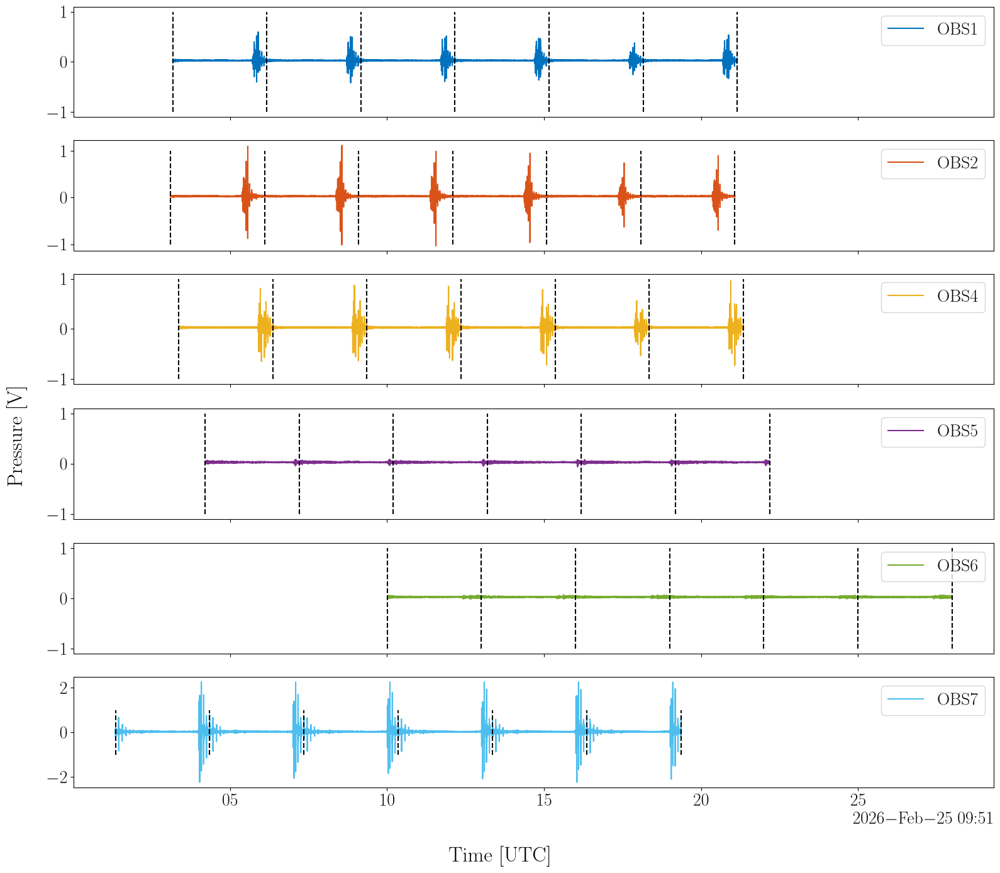

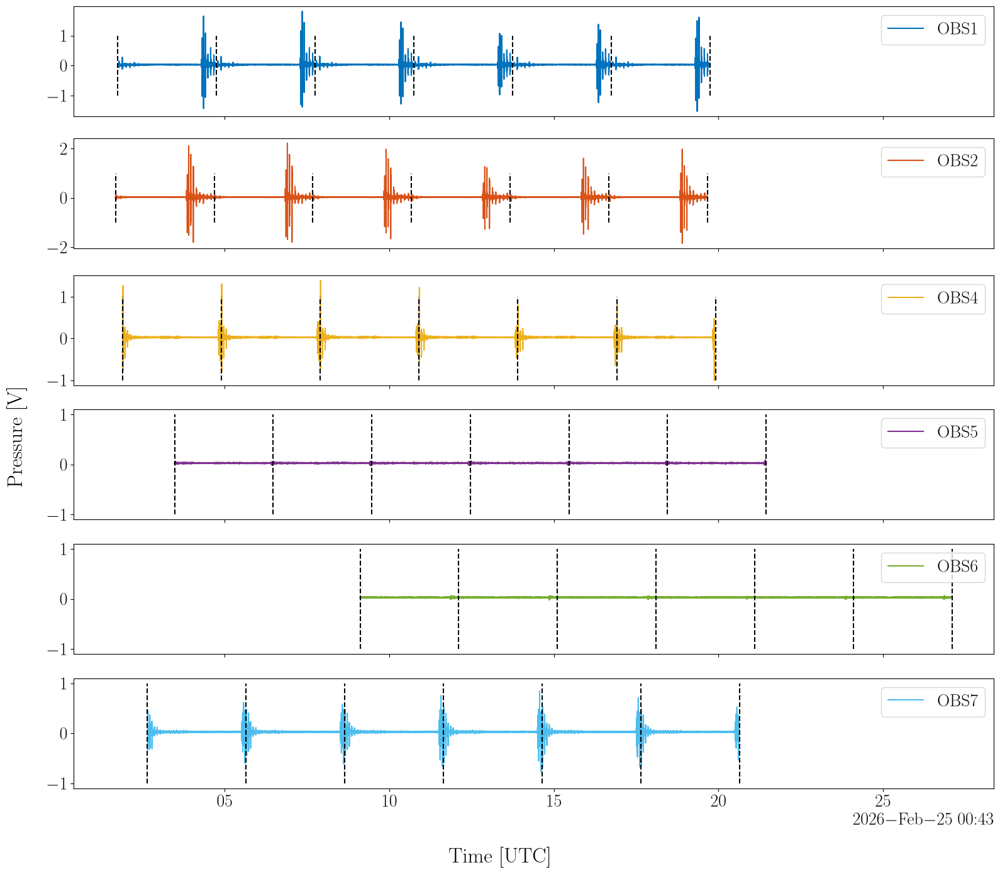

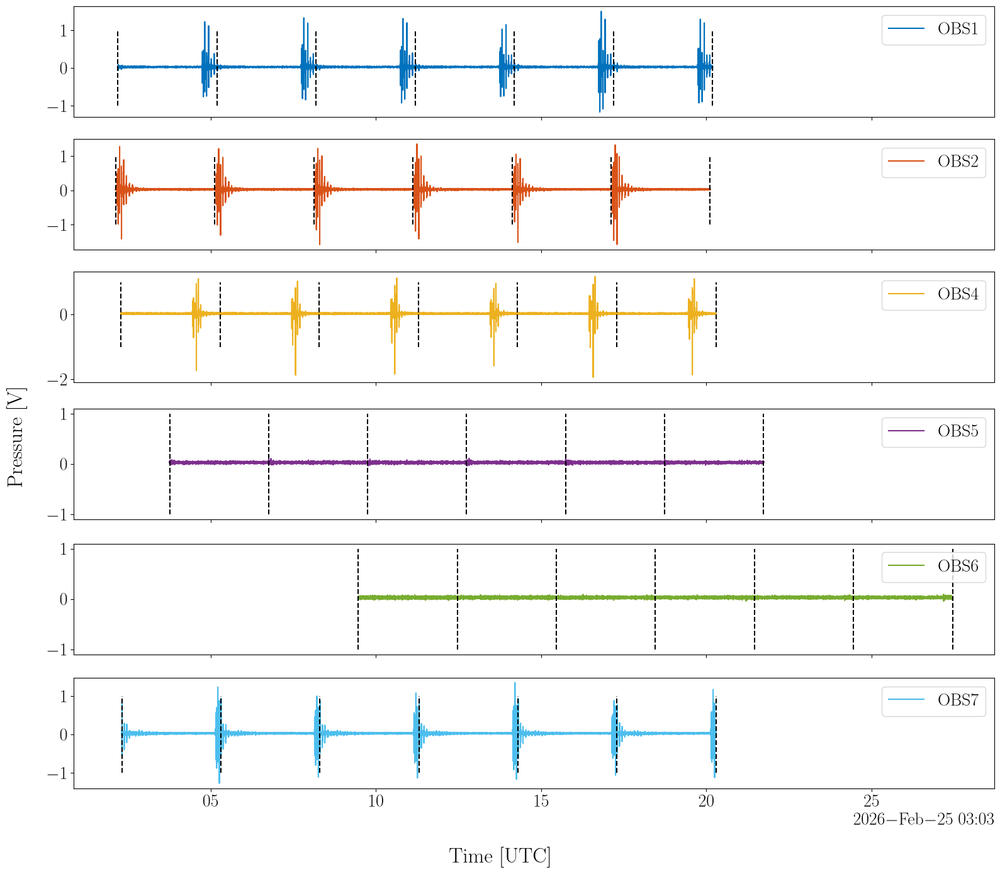

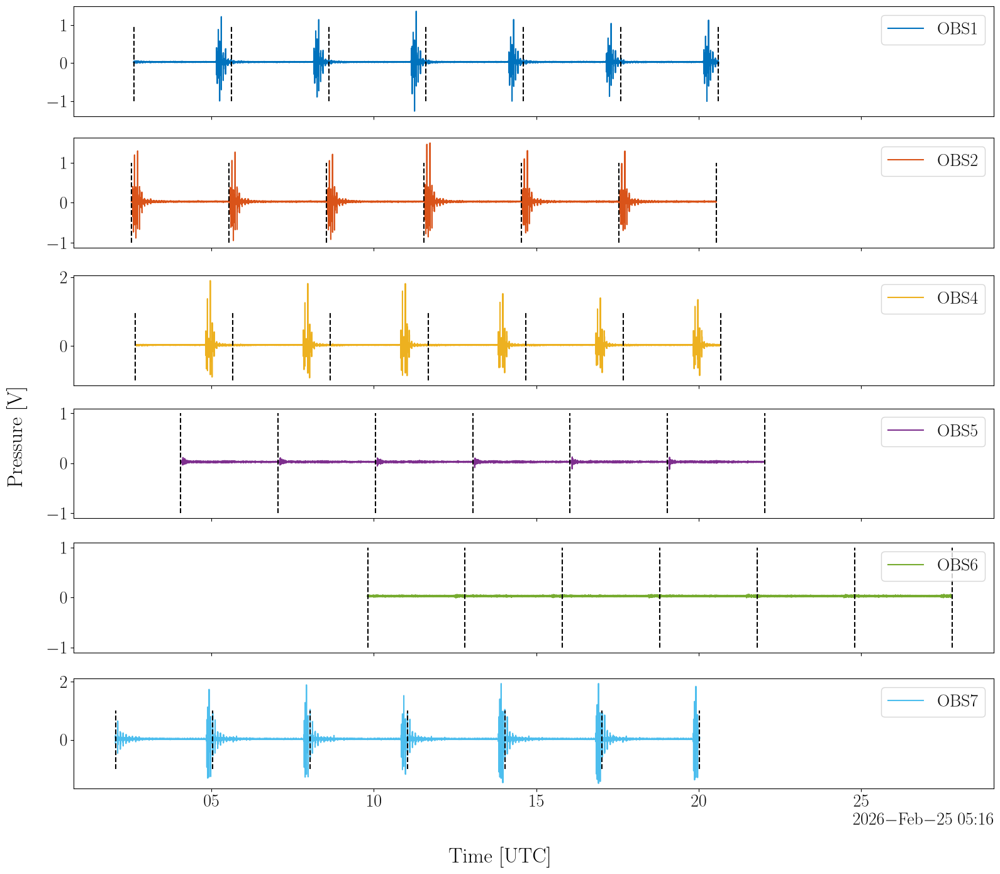

In [31]:
nb_tir = 5

for name, node in portion.pressure.children.items():
    ds_pressure_section = node.to_dataset()  
    # Associated ds_pos
    ds_pos_section = portion.position[name].to_dataset()
    tir_dt = ds_pos_section["tir_reception_datetime"].isel(src_datetime=slice(20, 20+nb_tir+2))

    fig, axs = plt.subplots(nrows=ds_pressure_section.obs_id.size, ncols=1, figsize=(16, 14), sharex=True)        
    axs = axs.flatten()
    for i, rcv_id in enumerate(ds_pressure_section.obs_id.values):
        tir_dt_rcv = tir_dt.sel(rcv_id=rcv_id)
        # Select associated data window 
        press_rcv = ds_pressure_section[f"pressure_{rcv_id}"].sel({f"time_{rcv_id}":slice(tir_dt_rcv.values[0], tir_dt_rcv.values[-1])})
        # Plot pressure signal 
        press_rcv.plot(label=rcv_id.upper(), color=color(i), ax=axs[i])
        # Plot arrivals time 
        axs[i].vlines(x=tir_dt_rcv, ymin=-1, ymax=1, color="k", linestyle="--")
        # Add legend
        axs[i].legend(loc="upper right")

    xlab = axs[0].get_xlabel()
    ylab = axs[0].get_ylabel()

    for ax in axs:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")
    
    fig.supxlabel(xlab)
    fig.supylabel(ylab)

    plt.show()

### Découpage et calcul des grandeurs signantes 

In [ ]:
def compute_sxy_scot(
    ds_arr,
    signals,
    times,
    num_obs,
    den_obs,
    ref_obs=None,
    window_mode="common",
    fs=2000,
    offset_s=0.1,
    pulse_len_s=None,
    nfft=2**16,
    n_smooth=5,
):
    """Estimate the Sxy_scot = S_{num,den} / sqrt(S_{num,num} S_{den,den}) for each pulse.


    Parameters
    ----------
    ds_arr, signals, times, fs, offset_s, pulse_len_s, window_mode, ref_obs
        See `extract_pulse_windows`.
    num_obs : list of str
        Sensors in the numerator (e.g. [4, 1, 6]).
    den_obs : str
        Sensor in the denominator (e.g. 7).
    nfft : int
        FFT length (zero-padding if larger than the window).
    n_smooth : int
        Length of the moving average applied to the RTF magnitude in dB.

    Returns
    -------
    _type_
        _description_

    """

    all_obs = list(dict.fromkeys([*num_obs, den_obs, *(ref_obs or [])]))
    windows, idx_start = extract_pulse_windows(
        ds_arr,
        {o: signals[o] for o in all_obs},
        times,
        fs,
        offset_s,
        pulse_len_s,
        window_mode=window_mode,
        ref_obs=ref_obs,
    )

    # Remove last to avoid nan
    for o in all_obs:
        idx_start[o] = idx_start[o][:-1]
        windows[o] = windows[o][:-1]

    freq = np.fft.rfftfreq(nfft, d=1 / fs)
    fft = {o: np.fft.rfft(windows[o], n=nfft, axis=-1) for o in all_obs}

    # Auto-spectrums
    s_den = fft[den_obs] * np.conj(fft[den_obs])
    sxy_scot = np.stack(
        [
            (fft[o] * np.conj(fft[den_obs]))
            / (np.sqrt(s_den * fft[o] * np.conj(fft[o])) + 1e-12)
            for o in num_obs
        ]
    )

    # Compute
    # sxy = []
    cxy_ = []
    y = windows[den_obs]
    for o in num_obs:
        x = windows[o]
        n = x.shape[1]
        nfft = 2 * n - 1  # Zero pad to compute full correlation

        x_fft = np.fft.fft(x, n=nfft, axis=1)
        y_fft = np.fft.fft(y, n=nfft, axis=1)

        # # Sxy
        # sxy_o = x_fft * np.conj(y_fft)

        c_xy = np.fft.ifft(x_fft * np.conj(y_fft), axis=1)
        c_xy = np.real(c_xy)
        c_xy = np.fft.fftshift(c_xy, axes=1)
        # c_xy = sp.correlate(x, y, axis=1)

        cxy_.append(c_xy)

    tau = sp.correlation_lags(x.shape[1], y.shape[1], mode="full") * 1/fs
    cxy = np.stack(cxy_)
    

    rtf_id = [f"{o}/{den_obs}" for o in num_obs]
    dims = ("rtf_id", "pulse_id", "freq")
    return xr.Dataset(
        data_vars=dict(
            sxy_scot=(dims, sxy_scot),
            cxy=(("rtf_id", "pulse_id", "lag"), cxy),
            idx_start=(
                ("obs_id", "pulse_id"),
                np.stack([idx_start[o] for o in all_obs]),
            ),
        ),
        coords=dict(
            rtf_id=rtf_id,
            obs_id=all_obs,
            pulse_id=np.arange(windows[all_obs[0]].shape[0]),
            freq=freq,
            lag=tau,
        ),
        attrs=dict(
            fs=fs,
            offset_s=offset_s,
            nfft=nfft,
            den_obs=den_obs,
            window_mode=window_mode,
            n_smooth=n_smooth,
        ),
    )

In [ ]:
    # Compute cross spectrum S12 = X1 conj(X2)
    nfft = 2**16
    f_fft = np.fft.rfftfreq(nfft, d=1 / fs)
    fft_obs4 = np.fft.rfft(pulse_obs4, n=nfft)
    fft_obs7 = np.fft.rfft(pulse_obs7, n=nfft)
    sxy = fft_obs4 * np.conj(fft_obs7)
    syy = fft_obs7 * np.conj(fft_obs7)

    pi_xy = sxy / syy